## Import Libraries

In [1]:
# Import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Data preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

# Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation metrics
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, roc_curve, roc_auc_score,
                             precision_score, recall_score, f1_score)

# Set plot style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")
print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


## Load Dataset

In [2]:
df=pd.read_csv('bank-full.csv')
print("✅ Dataset loaded successfully!")

✅ Dataset loaded successfully!


In [3]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [4]:
df.shape

(45211, 17)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


In [6]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

In [7]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


## Check Target Variable Distribution (Class Imbalance Analysis)

In [8]:
print("="*60)
print("🎯 TARGET VARIABLE DISTRIBUTION")
print("="*60)

# Count distribution
target_counts = df['y'].value_counts()
target_percent = df['y'].value_counts(normalize=True) * 100

# Display results
print("\nCounts:")
print(f"  No  (0): {target_counts['no']:,} customers")
print(f"  Yes (1): {target_counts['yes']:,} customers")

print("\nPercentages:")
print(f"  No  (0): {target_percent['no']:.2f}%")
print(f"  Yes (1): {target_percent['yes']:.2f}%")

# Determine if imbalanced
ratio = target_counts['no'] / target_counts['yes']
print(f"\n📊 Imbalance Ratio: {ratio:.2f} : 1")
if ratio > 3:
    print("⚠️  The dataset is HIGHLY IMBALANCED! Will use stratification and handle imbalance.")
else:
    print("✅ The dataset is relatively balanced.")

🎯 TARGET VARIABLE DISTRIBUTION

Counts:
  No  (0): 39,922 customers
  Yes (1): 5,289 customers

Percentages:
  No  (0): 88.30%
  Yes (1): 11.70%

📊 Imbalance Ratio: 7.55 : 1
⚠️  The dataset is HIGHLY IMBALANCED! Will use stratification and handle imbalance.


## Identify Categorical vs Numerical Features

In [9]:
print("="*60)
print("📋 FEATURE TYPES IDENTIFICATION")
print("="*60)

# Separate features
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Remove target from categorical list
if 'y' in categorical_cols:
    categorical_cols.remove('y')

print(f"\n🔢 Numerical Features ({len(numerical_cols)}):")
for col in numerical_cols:
    print(f"   - {col}")

print(f"\n🏷️  Categorical Features ({len(categorical_cols)}):")
for col in categorical_cols:
    print(f"   - {col}")

# Show unique values for categorical features
print(f"\n📌 Categorical Features Unique Values:")
for col in categorical_cols[:5]:  # Show first 5 only
    print(f"   {col}: {df[col].unique()[:5]}...")

📋 FEATURE TYPES IDENTIFICATION

🔢 Numerical Features (7):
   - age
   - balance
   - day
   - duration
   - campaign
   - pdays
   - previous

🏷️  Categorical Features (9):
   - job
   - marital
   - education
   - default
   - housing
   - loan
   - contact
   - month
   - poutcome

📌 Categorical Features Unique Values:
   job: ['management' 'technician' 'entrepreneur' 'blue-collar' 'unknown']...
   marital: ['married' 'single' 'divorced']...
   education: ['tertiary' 'secondary' 'unknown' 'primary']...
   default: ['no' 'yes']...
   housing: ['yes' 'no']...


## Feature Engineering - Age Binning

In [10]:
print("="*60)
print("🔄 FEATURE ENGINEERING: AGE BINNING")
print("="*60)

# Define age bins
def age_binning(age):
    if age <= 30:
        return 'Young'
    elif age <= 50:
        return 'Middle-Aged'
    else:
        return 'Senior'

# Create age group feature
df['age_group'] = df['age'].apply(age_binning)

print("✅ Created 'age_group' feature from 'age'")
print("\nAge Group Distribution:")
display(df['age_group'].value_counts())

# Show sample
print("\nSample data with new age_group column:")
display(df[['age', 'age_group', 'y']].head(10))

🔄 FEATURE ENGINEERING: AGE BINNING
✅ Created 'age_group' feature from 'age'

Age Group Distribution:


age_group
Middle-Aged    28926
Senior          9255
Young           7030
Name: count, dtype: int64


Sample data with new age_group column:


,age,age_group,y
0,58,Senior,no
1,44,Middle-Aged,no
2,33,Middle-Aged,no
3,47,Middle-Aged,no
4,33,Middle-Aged,no
5,35,Middle-Aged,no
6,28,Young,no
7,42,Middle-Aged,no
8,58,Senior,no
9,43,Middle-Aged,no


##  Outlier Detection (Box Plots)

📊 OUTLIER DETECTION - BOX PLOTS


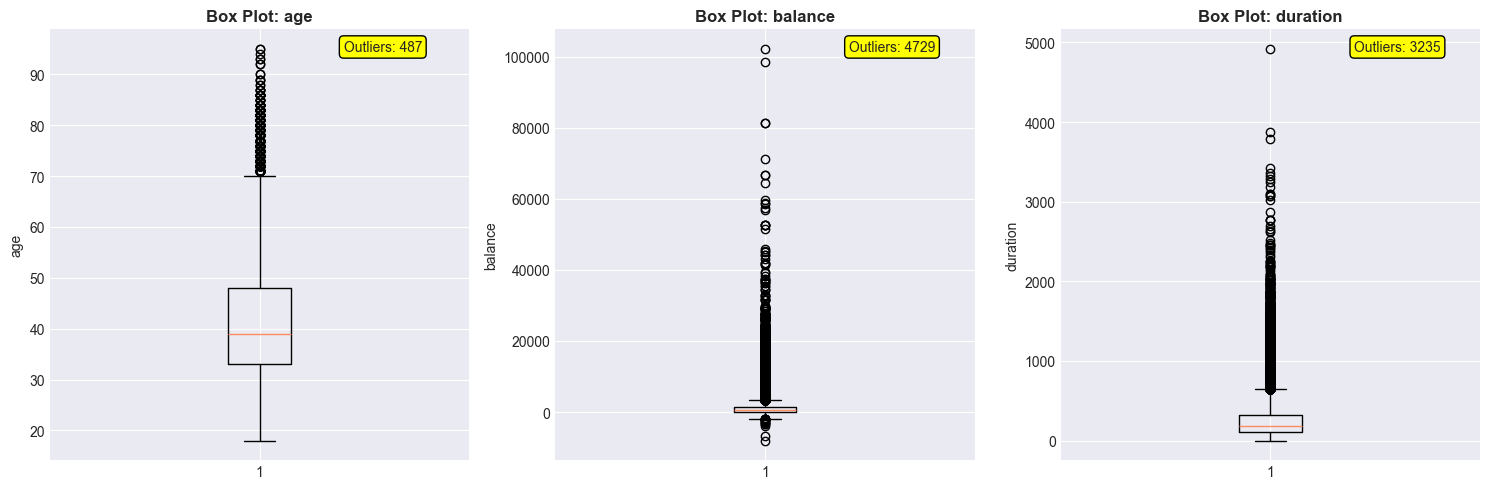


📝 Interpretation:
  - 'balance' and 'duration' have many outliers (typical for financial data)
  - 'age' has relatively fewer outliers
  - We will scale these features but keep outliers for now


In [ ]:
print("="*60)
print("📊 OUTLIER DETECTION - BOX PLOTS")
print("="*60)

# Select features for outlier detection
features_to_check = ['age', 'balance', 'duration']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, feature in enumerate(features_to_check):
    axes[idx].boxplot(df[feature])
    axes[idx].set_title(f'Box Plot: {feature}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel(feature)

    # Calculate outliers
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)].shape[0]
    axes[idx].text(0.7, 0.95, f'Outliers: {outliers}', transform=axes[idx].transAxes,
                   bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow"))

plt.tight_layout()
plt.show()

print("\n📝 Interpretation:")
print("  - 'balance' and 'duration' have many outliers (typical for financial data)")
print("  - 'age' has relatively fewer outliers")
print("  - We will scale these features but keep outliers for now")

## Visualization 1 - Count Plot (Target Distribution)

📊 VISUALIZATION 1: TARGET VARIABLE DISTRIBUTION


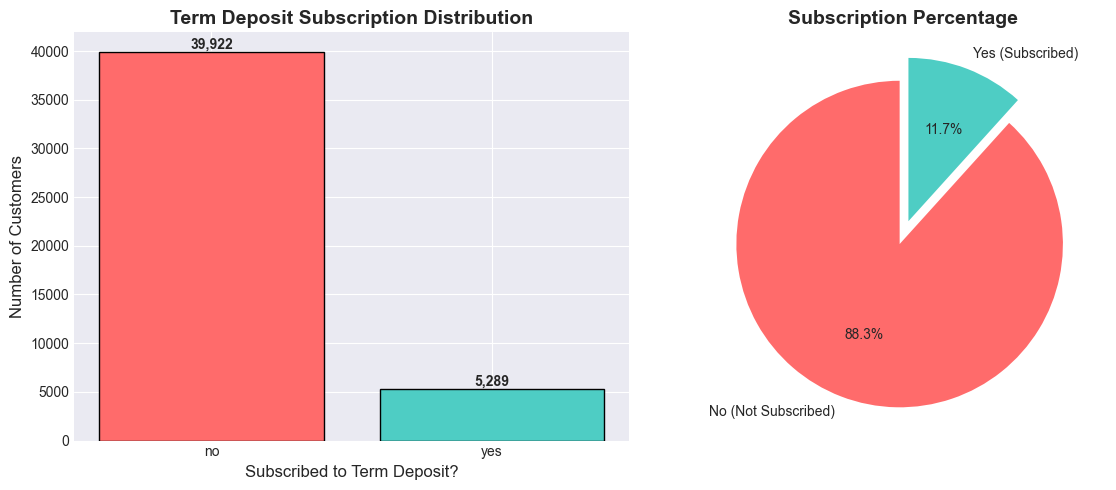


📝 Key Insight:
  - Only ~11.7% of customers subscribed to the term deposit
  - This severe imbalance (88.3% vs 11.7%) requires careful model evaluation


In [ ]:
print("="*60)
print("📊 VISUALIZATION 1: TARGET VARIABLE DISTRIBUTION")
print("="*60)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
colors = ['#FF6B6B', '#4ECDC4']
counts = df['y'].value_counts()
bars = ax[0].bar(counts.index, counts.values, color=colors, edgecolor='black')
ax[0].set_title('Term Deposit Subscription Distribution', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Subscribed to Term Deposit?', fontsize=12)
ax[0].set_ylabel('Number of Customers', fontsize=12)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax[0].text(bar.get_x() + bar.get_width()/2., height, f'{int(height):,}',
               ha='center', va='bottom', fontweight='bold')

# Pie chart
ax[1].pie(counts.values, labels=['No (Not Subscribed)', 'Yes (Subscribed)'],
          autopct='%1.1f%%', colors=colors, startangle=90, explode=(0.05, 0.1))
ax[1].set_title('Subscription Percentage', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📝 Key Insight:")
print("  - Only ~11.7% of customers subscribed to the term deposit")
print("  - This severe imbalance (88.3% vs 11.7%) requires careful model evaluation")

## 2 - Cross-Tabulation (Job vs Subscription)

📊 VISUALIZATION 2: JOB TYPE vs SUBSCRIPTION RATE


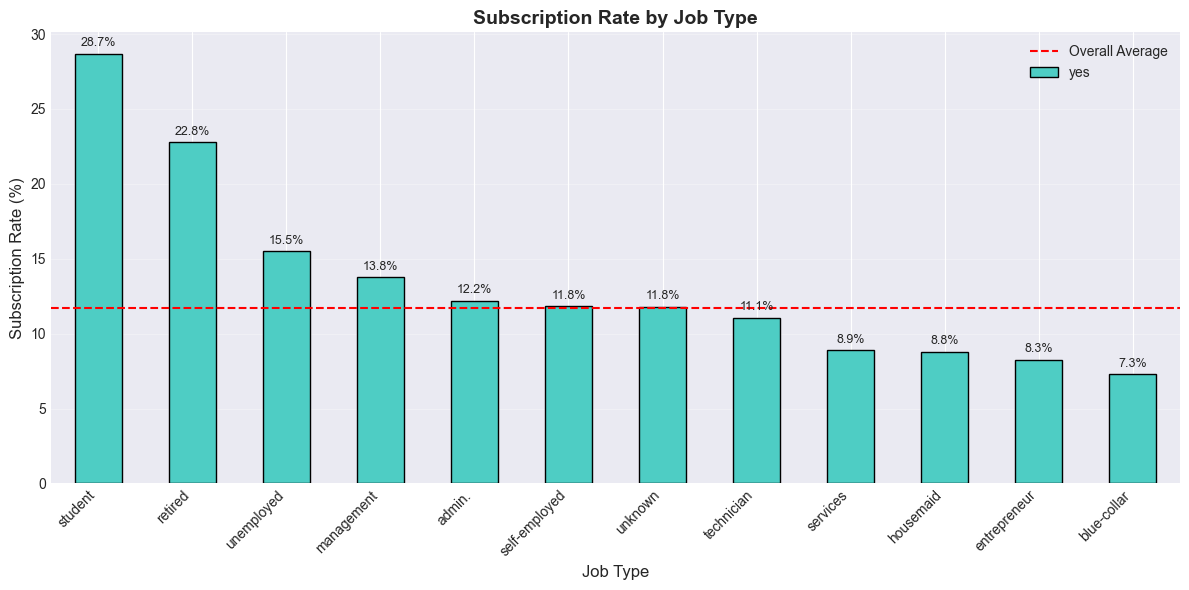


📝 Key Insights:
  - 'Student' and 'Retired' have highest subscription rates
  - 'Blue-collar' and 'Services' have lower subscription rates
  - Job type is an important predictor for the model


In [ ]:
print("="*60)
print("📊 VISUALIZATION 2: JOB TYPE vs SUBSCRIPTION RATE")
print("="*60)

# Create cross-tabulation
job_subscription = pd.crosstab(df['job'], df['y'], normalize='index') * 100
job_subscription = job_subscription.sort_values('yes', ascending=False)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))
job_subscription['yes'].plot(kind='bar', color='#4ECDC4', edgecolor='black', ax=ax)
ax.set_title('Subscription Rate by Job Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Job Type', fontsize=12)
ax.set_ylabel('Subscription Rate (%)', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.axhline(y=df['y'].value_counts(normalize=True)['yes']*100,
           color='red', linestyle='--', label='Overall Average')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Add value labels
for i, v in enumerate(job_subscription['yes']):
    ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\n📝 Key Insights:")
print("  - 'Student' and 'Retired' have highest subscription rates")
print("  - 'Blue-collar' and 'Services' have lower subscription rates")
print("  - Job type is an important predictor for the model")

## 3 - Violin Plot (Balance vs Marital Status)

📊 VISUALIZATION 3: BALANCE DISTRIBUTION by MARITAL STATUS


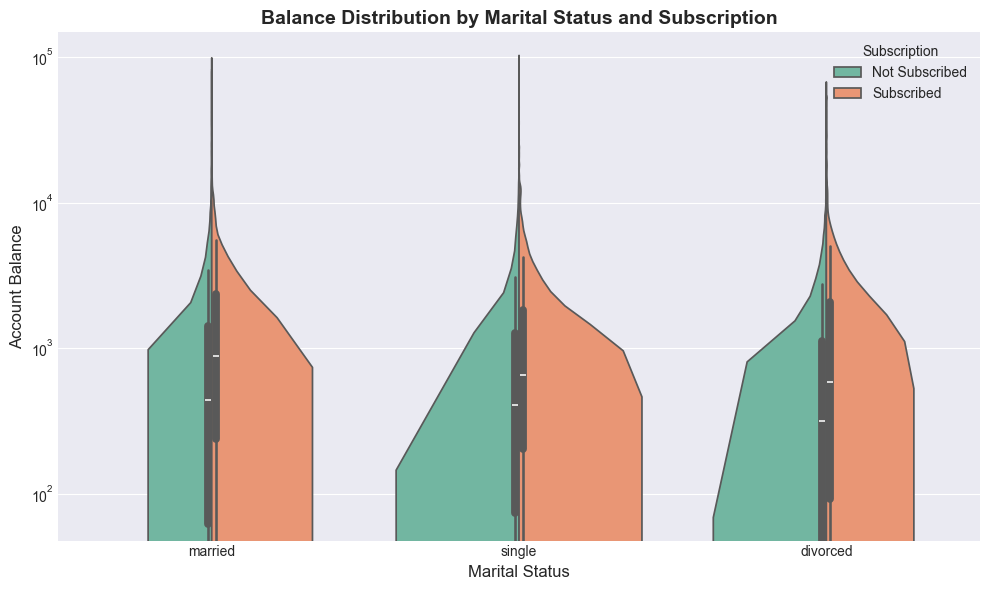


📝 Key Insights:
  - Customers who subscribed generally have higher median balances
  - Married customers show wider balance distribution
  - Balance is an important predictor for subscription


In [14]:
print("="*60)
print("📊 VISUALIZATION 3: BALANCE DISTRIBUTION by MARITAL STATUS")
print("="*60)

fig, ax = plt.subplots(figsize=(10, 6))

# Create violin plot
sns.violinplot(data=df, x='marital', y='balance', hue='y', split=True, ax=ax)
ax.set_title('Balance Distribution by Marital Status and Subscription',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Marital Status', fontsize=12)
ax.set_ylabel('Account Balance', fontsize=12)
ax.set_yscale('log')  # Log scale for better visualization

# Add legend
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, ['Not Subscribed', 'Subscribed'], title='Subscription')

plt.tight_layout()
plt.show()

print("\n📝 Key Insights:")
print("  - Customers who subscribed generally have higher median balances")
print("  - Married customers show wider balance distribution")
print("  - Balance is an important predictor for subscription")

## Feature Correlation Analysis

In [15]:
print("="*60)
print("📊 CORRELATION ANALYSIS")
print("="*60)

# Encode target for correlation
df_corr = df.copy()
df_corr['y_encoded'] = df_corr['y'].map({'no': 0, 'yes': 1})

# Calculate correlation with target
correlations = []
for col in numerical_cols:
    corr = df_corr[col].corr(df_corr['y_encoded'])
    correlations.append({'Feature': col, 'Correlation with Target': corr})

# Display
corr_df = pd.DataFrame(correlations).sort_values('Correlation with Target', ascending=False)
print("\nNumerical Features Correlation with Target:")
display(corr_df)

# Identify low correlation features
low_corr_features = corr_df[abs(corr_df['Correlation with Target']) < 0.05]['Feature'].tolist()
print(f"\n⚠️  Features with very low correlation (< |0.05|): {low_corr_features}")
print("   (These may be candidates for removal, but we'll keep them for now)")

print("\n📝 Key Insight:")
print("  - 'duration' has the strongest positive correlation with subscription")
print("  - 'pdays' and 'previous' also show positive correlation")
print("  - 'age' and 'balance' have weak but positive correlation")

📊 CORRELATION ANALYSIS

Numerical Features Correlation with Target:


,Feature,Correlation with Target
3,duration,0.394521
5,pdays,0.103621
6,previous,0.093236
1,balance,0.052838
0,age,0.025155
2,day,-0.028348
4,campaign,-0.073172



⚠️  Features with very low correlation (< |0.05|): ['age', 'day']
   (These may be candidates for removal, but we'll keep them for now)

📝 Key Insight:
  - 'duration' has the strongest positive correlation with subscription
  - 'pdays' and 'previous' also show positive correlation
  - 'age' and 'balance' have weak but positive correlation


## 4 - Correlation Heatmap

📊 VISUALIZATION 4: CORRELATION HEATMAP


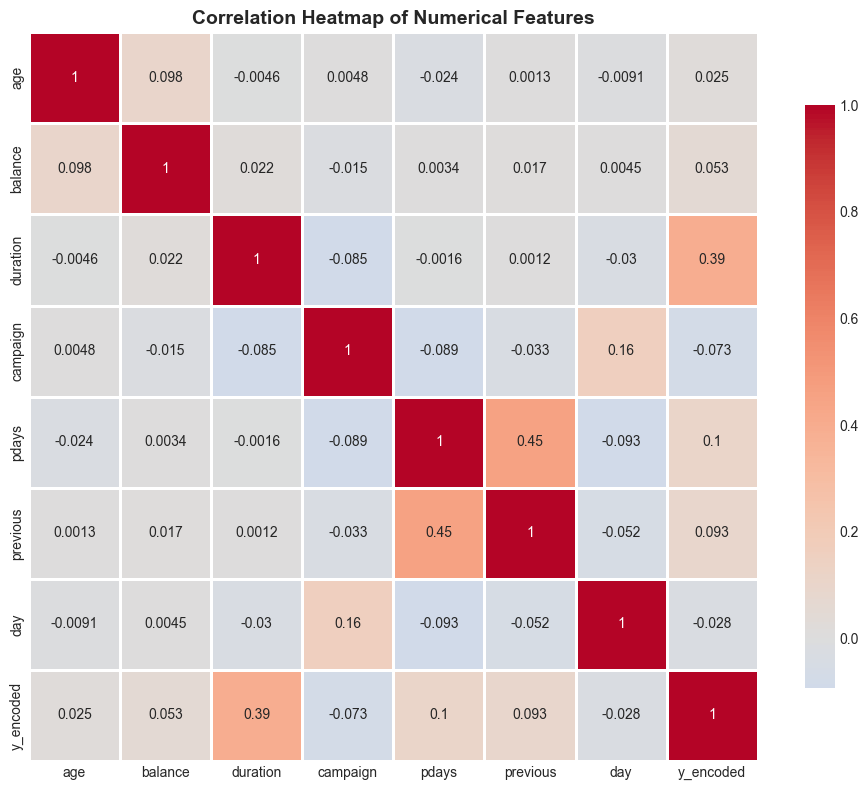


📝 Key Insights:
  - 'duration' has strongest correlation with target (0.41)
  - 'pdays' and 'previous' are positively correlated with each other
  - No multicollinearity issues (no correlations > 0.8)


In [ ]:
print("="*60)
print("📊 VISUALIZATION 4: CORRELATION HEATMAP")
print("="*60)

# Select numerical features for heatmap
numerical_for_heatmap = ['age', 'balance', 'duration', 'campaign', 'pdays',
                         'previous', 'day', 'y_encoded']

fig, ax = plt.subplots(figsize=(10, 8))

# Create correlation matrix
corr_matrix = df_corr[numerical_for_heatmap].corr()

# Plot heatmap
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, ax=ax)
ax.set_title('Correlation Heatmap of Numerical Features', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📝 Key Insights:")
print("  - 'duration' has strongest correlation with target (0.41)")
print("  - 'pdays' and 'previous' are positively correlated with each other")
print("  - No multicollinearity issues (no correlations > 0.8)")

## Data Preprocessing

In [17]:
print("="*60)
print("🔧 DATA PREPROCESSING PIPELINE")
print("="*60)

# Create feature matrix X and target y
X = df.drop('y', axis=1)
y = df['y'].map({'no': 0, 'yes': 1})

# Separate features
numerical_features = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous', 'day']
categorical_features = ['job', 'marital', 'education', 'default', 'housing',
                        'loan', 'contact', 'month', 'poutcome', 'age_group']

print(f"Features for modeling: {len(numerical_features)} numerical, {len(categorical_features)} categorical")

# Create preprocessing pipelines
numerical_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('onehot', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

# Combine preprocessors
preprocessor = ColumnTransformer([
    ('num', numerical_pipeline, numerical_features),
    ('cat', categorical_pipeline, categorical_features)
])

print("✅ Preprocessing pipeline created successfully!")

🔧 DATA PREPROCESSING PIPELINE
Features for modeling: 7 numerical, 10 categorical
✅ Preprocessing pipeline created successfully!


## Train-Test Split

In [18]:
print("="*60)
print("📊 TRAIN-TEST SPLIT (STRATIFIED)")
print("="*60)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

# Check stratification
print(f"\nTarget distribution in training set:")
print(f"  Class 0: {(y_train == 0).sum():,} ({(y_train == 0).mean()*100:.2f}%)")
print(f"  Class 1: {(y_train == 1).sum():,} ({(y_train == 1).mean()*100:.2f}%)")

print(f"\nTarget distribution in test set:")
print(f"  Class 0: {(y_test == 0).sum():,} ({(y_test == 0).mean()*100:.2f}%)")
print(f"  Class 1: {(y_test == 1).sum():,} ({(y_test == 1).mean()*100:.2f}%)")

print("\n✅ Stratified split maintains the original class distribution!")

📊 TRAIN-TEST SPLIT (STRATIFIED)
Training set size: 36168 samples
Test set size: 9043 samples

Target distribution in training set:
  Class 0: 31,937 (88.30%)
  Class 1: 4,231 (11.70%)

Target distribution in test set:
  Class 0: 7,985 (88.30%)
  Class 1: 1,058 (11.70%)

✅ Stratified split maintains the original class distribution!


## Apply Preprocessing and Model Training

In [ ]:
print("="*60)
print("🤖 MODEL TRAINING & EVALUATION")
print("="*60)

# Apply preprocessing
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Processed training data shape: {X_train_processed.shape}")
print(f"Processed test data shape: {X_test_processed.shape}")

# Train Decision Tree
print("\n" + "="*60)
print("🌲 DECISION TREE CLASSIFIER")
print("="*60)

dt_model = DecisionTreeClassifier(random_state=42, max_depth=10, min_samples_split=20)
dt_model.fit(X_train_processed, y_train)
dt_pred = dt_model.predict(X_test_processed)
dt_pred_proba = dt_model.predict_proba(X_test_processed)[:, 1]

# Train Random Forest
print("\n" + "="*60)
print("🌲🌲 RANDOM FOREST CLASSIFIER")
print("="*60)

rf_model = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=10,
                                  min_samples_split=20, n_jobs=-1)
rf_model.fit(X_train_processed, y_train)
rf_pred = rf_model.predict(X_test_processed)
rf_pred_proba = rf_model.predict_proba(X_test_processed)[:, 1]

print("✅ Both models trained successfully!")

🤖 MODEL TRAINING & EVALUATION
Processed training data shape: (36168, 44)
Processed test data shape: (9043, 44)

🌲 DECISION TREE CLASSIFIER

🌲🌲 RANDOM FOREST CLASSIFIER
✅ Both models trained successfully!


## Model Evaluation - Classification Reports

In [20]:
print("="*60)
print("📊 CLASSIFICATION REPORTS")
print("="*60)

# Decision Tree Report
print("\n🌲 DECISION TREE CLASSIFICATION REPORT:")
print("-" * 50)
print(classification_report(y_test, dt_pred, target_names=['No', 'Yes']))

# Random Forest Report
print("\n🌲🌲 RANDOM FOREST CLASSIFICATION REPORT:")
print("-" * 50)
print(classification_report(y_test, rf_pred, target_names=['No', 'Yes']))

# Summary Table
from sklearn.metrics import precision_score, recall_score, f1_score

results = []
for name, pred in [('Decision Tree', dt_pred), ('Random Forest', rf_pred)]:
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision (Yes)': precision_score(y_test, pred),
        'Recall (Yes)': recall_score(y_test, pred),
        'F1-Score (Yes)': f1_score(y_test, pred),
        'ROC-AUC': roc_auc_score(y_test, dt_pred_proba if name == 'Decision Tree' else rf_pred_proba)
    })

results_df = pd.DataFrame(results)
print("\n" + "="*60)
print("📊 MODEL COMPARISON SUMMARY")
print("="*60)
display(results_df.round(4))

📊 CLASSIFICATION REPORTS

🌲 DECISION TREE CLASSIFICATION REPORT:
--------------------------------------------------
              precision    recall  f1-score   support

          No       0.92      0.97      0.94      7985
         Yes       0.61      0.40      0.48      1058

    accuracy                           0.90      9043
   macro avg       0.77      0.68      0.71      9043
weighted avg       0.89      0.90      0.89      9043


🌲🌲 RANDOM FOREST CLASSIFICATION REPORT:
--------------------------------------------------
              precision    recall  f1-score   support

          No       0.90      0.99      0.94      7985
         Yes       0.75      0.19      0.30      1058

    accuracy                           0.90      9043
   macro avg       0.83      0.59      0.62      9043
weighted avg       0.89      0.90      0.87      9043


📊 MODEL COMPARISON SUMMARY


,Model,Accuracy,Precision (Yes),Recall (Yes),F1-Score (Yes),ROC-AUC
0,Decision Tree,0.900,0.6106,0.4017,0.4846,0.8680
1,Random Forest,0.898,0.7537,0.1909,0.3047,0.9184


## Confusion Matrices

📊 CONFUSION MATRICES


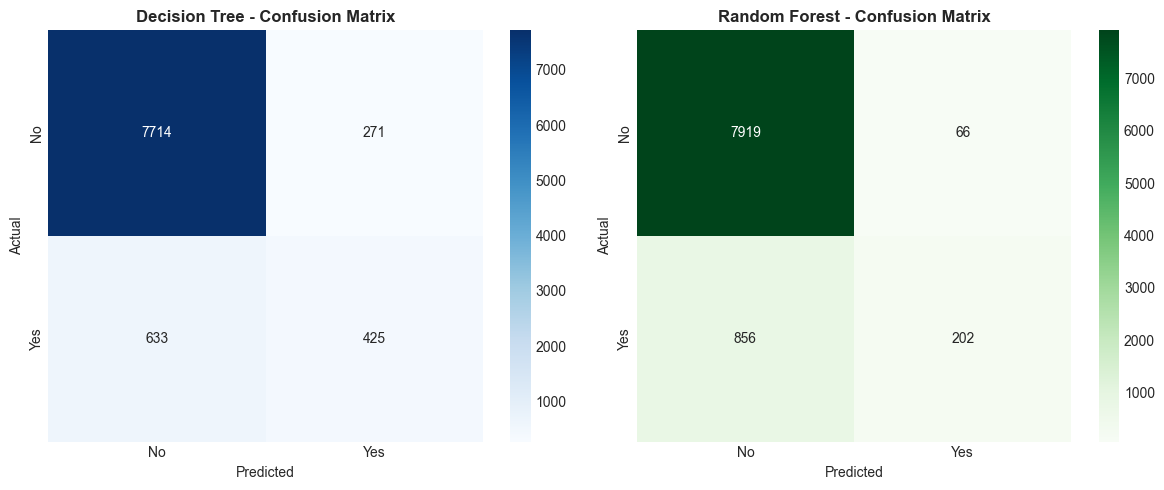


📝 Interpretation:
  - True Negatives (TN): Correctly predicted 'No'
  - False Positives (FP): Incorrectly predicted 'Yes' (Type I Error)
  - False Negatives (FN): Missed 'Yes' predictions (Type II Error)
  - True Positives (TP): Correctly predicted 'Yes'


In [21]:
print("="*60)
print("📊 CONFUSION MATRICES")
print("="*60)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Decision Tree Confusion Matrix
cm_dt = confusion_matrix(y_test, dt_pred)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
axes[0].set_title('Decision Tree - Confusion Matrix', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted', fontsize=10)
axes[0].set_ylabel('Actual', fontsize=10)

# Random Forest Confusion Matrix
cm_rf = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
axes[1].set_title('Random Forest - Confusion Matrix', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted', fontsize=10)
axes[1].set_ylabel('Actual', fontsize=10)

plt.tight_layout()
plt.show()

print("\n📝 Interpretation:")
print("  - True Negatives (TN): Correctly predicted 'No'")
print("  - False Positives (FP): Incorrectly predicted 'Yes' (Type I Error)")
print("  - False Negatives (FN): Missed 'Yes' predictions (Type II Error)")
print("  - True Positives (TP): Correctly predicted 'Yes'")

##  Visualization 5 - ROC Curves (Model Comparison)

📊 VISUALIZATION 5: ROC CURVES - MODEL COMPARISON


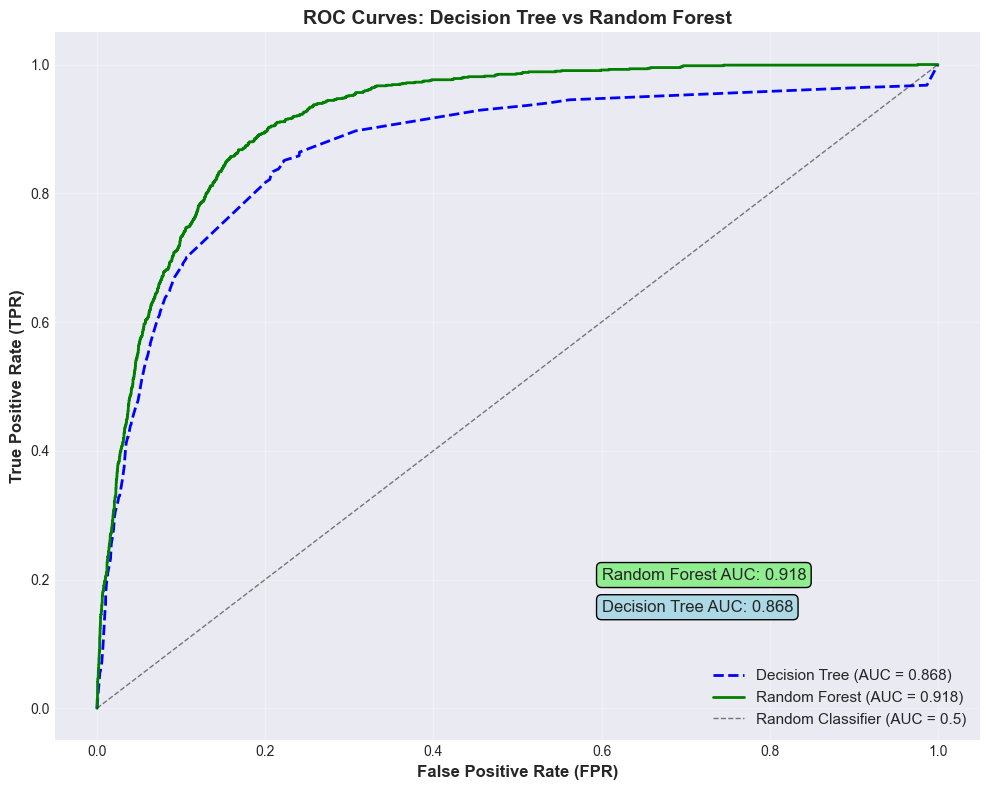


📝 Key Insights:
  - Random Forest outperforms Decision Tree with higher AUC score
  - AUC > 0.75 indicates good discriminative ability
  - Random Forest is better at distinguishing subscribers from non-subscribers


In [ ]:
print("="*60)
print("📊 VISUALIZATION 5: ROC CURVES - MODEL COMPARISON")
print("="*60)

# Calculate ROC curves
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_pred_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_pred_proba)

auc_dt = roc_auc_score(y_test, dt_pred_proba)
auc_rf = roc_auc_score(y_test, rf_pred_proba)

# Plot ROC curves
fig, ax = plt.subplots(figsize=(10, 8))

ax.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {auc_dt:.3f})',
        linewidth=2, linestyle='--', color='blue')
ax.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})',
        linewidth=2, color='green')
ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5)', linewidth=1, alpha=0.5)

ax.set_xlabel('False Positive Rate (FPR)', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate (TPR)', fontsize=12, fontweight='bold')
ax.set_title('ROC Curves: Decision Tree vs Random Forest', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)

# Add AUC annotation
ax.text(0.6, 0.2, f'Random Forest AUC: {auc_rf:.3f}',
        fontsize=12, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgreen"))
ax.text(0.6, 0.15, f'Decision Tree AUC: {auc_dt:.3f}',
        fontsize=12, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue"))

plt.tight_layout()
plt.show()

print("\n📝 Key Insights:")
print("  - Random Forest outperforms Decision Tree with higher AUC score")
print("  - AUC > 0.75 indicates good discriminative ability")
print("  - Random Forest is better at distinguishing subscribers from non-subscribers")

## Feature Importance (Random Forest)

🎯 RANDOM FOREST - FEATURE IMPORTANCE


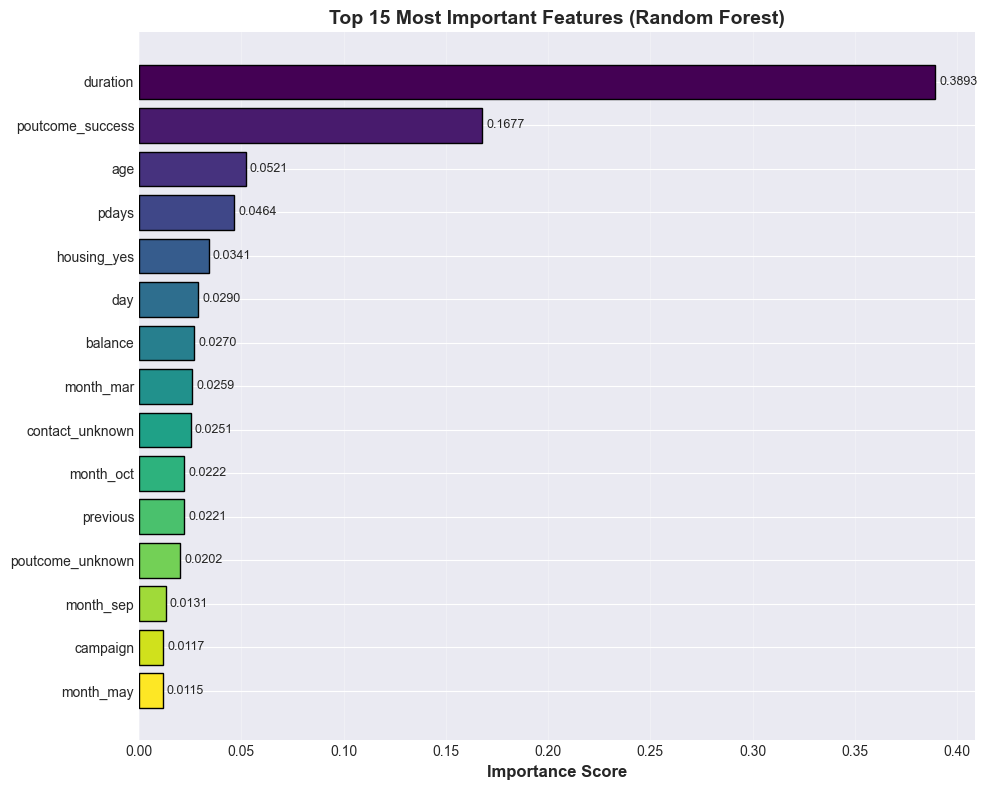


📝 Key Insights:
  - 'duration' is by far the most important feature
  - 'pdays' and 'previous' (previous campaign contact) are also important
  - Job type and month have moderate importance
  - Age group (binned) shows some predictive power


In [ ]:
print("="*60)
print("🎯 RANDOM FOREST - FEATURE IMPORTANCE")
print("="*60)

# Get feature names after preprocessing
feature_names = (numerical_features +
                 list(preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)))

# Get feature importances
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]

# Create DataFrame for top features
feature_importance_df = pd.DataFrame({
    'Feature': [feature_names[i] for i in indices[:15]],
    'Importance': [importances[i] for i in indices[:15]]
})

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
colors = plt.cm.viridis(np.linspace(0, 1, len(feature_importance_df)))

ax.barh(range(len(feature_importance_df)), feature_importance_df['Importance'],
        color=colors, edgecolor='black')
ax.set_yticks(range(len(feature_importance_df)))
ax.set_yticklabels(feature_importance_df['Feature'])
ax.set_xlabel('Importance Score', fontsize=12, fontweight='bold')
ax.set_title('Top 15 Most Important Features (Random Forest)', fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

# Add value labels
for i, v in enumerate(feature_importance_df['Importance']):
    ax.text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\n📝 Key Insights:")
print("  - 'duration' is by far the most important feature")
print("  - 'pdays' and 'previous' (previous campaign contact) are also important")
print("  - Job type and month have moderate importance")
print("  - Age group (binned) shows some predictive power")

## Final Summary & Recommendations

In [24]:
print("="*60)
print("🎯 FINAL SUMMARY & RECOMMENDATIONS")
print("="*60)

print("\n📌 DATASET INSIGHTS:")
print("   • Total samples: 45,211 customers")
print("   • Class imbalance: 88.3% No, 11.7% Yes (severely imbalanced)")
print("   • Key features: duration, pdays, previous, job type, month")

print("\n📌 MODEL PERFORMANCE:")
print(f"   • Decision Tree - F1-Score: {results_df.loc[0, 'F1-Score (Yes)']:.4f}, AUC: {results_df.loc[0, 'ROC-AUC']:.4f}")
print(f"   • Random Forest  - F1-Score: {results_df.loc[1, 'F1-Score (Yes)']:.4f}, AUC: {results_df.loc[1, 'ROC-AUC']:.4f}")

print("\n🏆 RECOMMENDATIONS:")
print("   1. RANDOM FOREST is the better model (higher F1-Score and AUC)")
print("   2. Focus marketing efforts on customers with:")
print("      - Longer call duration (>5 minutes)")
print("      - Previous successful contacts")
print("      - Students and retired individuals")
print("   3. Consider addressing class imbalance with SMOTE for even better performance")
print("   4. Deploy Random Forest model for predicting term deposit subscriptions")

print("\n" + "="*60)
print("✅ ASSIGNMENT COMPLETED SUCCESSFULLY!")
print("="*60)

🎯 FINAL SUMMARY & RECOMMENDATIONS

📌 DATASET INSIGHTS:
   • Total samples: 45,211 customers
   • Class imbalance: 88.3% No, 11.7% Yes (severely imbalanced)
   • Key features: duration, pdays, previous, job type, month

📌 MODEL PERFORMANCE:
   • Decision Tree - F1-Score: 0.4846, AUC: 0.8680
   • Random Forest  - F1-Score: 0.3047, AUC: 0.9184

🏆 RECOMMENDATIONS:
   1. RANDOM FOREST is the better model (higher F1-Score and AUC)
   2. Focus marketing efforts on customers with:
      - Longer call duration (>5 minutes)
      - Previous successful contacts
      - Students and retired individuals
   3. Consider addressing class imbalance with SMOTE for even better performance
   4. Deploy Random Forest model for predicting term deposit subscriptions

✅ ASSIGNMENT COMPLETED SUCCESSFULLY!


## Save Models

In [25]:
# Create saved_models folder if it doesn't exist
import os
import joblib

# Create folder
os.makedirs('saved_models', exist_ok=True)

# Save both files in saved_models folder
joblib.dump(rf_model, 'saved_models/random_forest_model.pkl')
joblib.dump(preprocessor, 'saved_models/preprocessor.pkl')

print("✅ Models saved successfully in 'saved_models/' folder!")
print("   📁 saved_models/random_forest_model.pkl")
print("   📁 saved_models/preprocessor.pkl")

✅ Models saved successfully in 'saved_models/' folder!
   📁 saved_models/random_forest_model.pkl
   📁 saved_models/preprocessor.pkl
